# forecast-spine — what point-in-time correctness actually looks like

This notebook exists to make one claim visible:

> Nothing used to produce a forecast for target hour `T` may have become
> available after `T − 24h`.

It is easy to state and easy to violate silently. The charts below show the
vintage structure that makes it a real problem, what the as-of selection picks
out of that structure, and what the same pipeline would report if the rule were
relaxed by a single predicate.

Everything is computed from the warehouse the pipeline builds. Nothing is
hard-coded; re-running the notebook re-derives every number.

**Reproducibility note.** ERCOT's public MIS listing retains only ~7 days of
NP3-565 forecast vintages, and `data/raw/` is gitignored. If those vintages are
not on disk the notebook falls back to synthetic fixtures and says so — the
charts still render, but the revision structure they are about will be absent.
See `MEMO.md §0`.

In [1]:
from __future__ import annotations

import datetime as dt
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from forecast_spine import fixtures, gates, pipeline, seasonal_naive, viz
from forecast_spine.time import hours_in_operating_date

viz.apply_style()
pd.set_option("display.width", 120)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = REPO / "data" / "raw"
SQL = REPO / "sql" / "asof_join.sql"

LIVE = any(RAW.glob("*/*_csv.zip"))
if LIVE:
    processing_date, raw_root, window_days = dt.date(2026, 9, 23), RAW, 5
else:
    import tempfile
    raw_root = fixtures.build("pass", Path(tempfile.mkdtemp()))
    processing_date, window_days = fixtures.processing_date_for("pass"), 1
    print(
        "LIVE VINTAGES NOT FOUND — falling back to synthetic fixtures.\n"
        "Charts render, but forecast revision structure is absent by construction.\n"
        "Run `forecast-spine acquire` for the real thing."
    )

context = pipeline.build_context(processing_date, raw_root, window_days=window_days)
con = pipeline.connect(":memory:")
pipeline.load(con, context)
pipeline.build_evaluation_dataset(con, con_ctx := context, SQL)

readiness = gates.data_readiness(con, context)
model_gate = gates.seasonal_naive_gate(con, context)
naive = seasonal_naive.evaluate(con, "naive")
ercot_model = seasonal_naive.evaluate(con, "ercot")

first_day, last_day = context.window_operating_dates
print(f"run_id            {context.run_id}")
print(f"processing date   {processing_date}   window {first_day} .. {last_day}")
print(f"source files      {readiness.metrics['source_files']}")
print(f"source rows       {readiness.metrics['raw_source_rows']:,} -> dispositions "
      f"{readiness.metrics['dispositions']}")
print(f"evaluation rows   {readiness.metrics['evaluation_rows']}")
print()
print(f"data_readiness    {readiness.status}")
print(f"seasonal_naive    {model_gate.status}   WAPE {naive.wape_pct:.2f}%")

run_id            aa989ae9f052f2ba6b64f73b08c95d16
processing date   2026-09-23   window 2026-09-18 .. 2026-09-22
source files      206
source rows       268,032 -> dispositions {'ACCEPTED': 268032}
evaluation rows   960

data_readiness    PASS
seasonal_naive    PASS   WAPE 6.35%


## 1. The vintage landscape

ERCOT republishes its seven-day forecast every hour. Each target hour is
therefore forecast well over a hundred times, and those forecasts disagree —
measured over this window, **99.7%** of target zone-hours change value across
vintages.

That is the whole reason this is a temporal-data problem. If forecasts never
changed, one snapshot would do and "as of when?" would be a question with no
consequences.

The dashed line is the `T − 24h` frontier. A point above it was published early
enough to inform a decision about its target hour; a point below it is hindsight
and is never used, however accurate it happens to be.

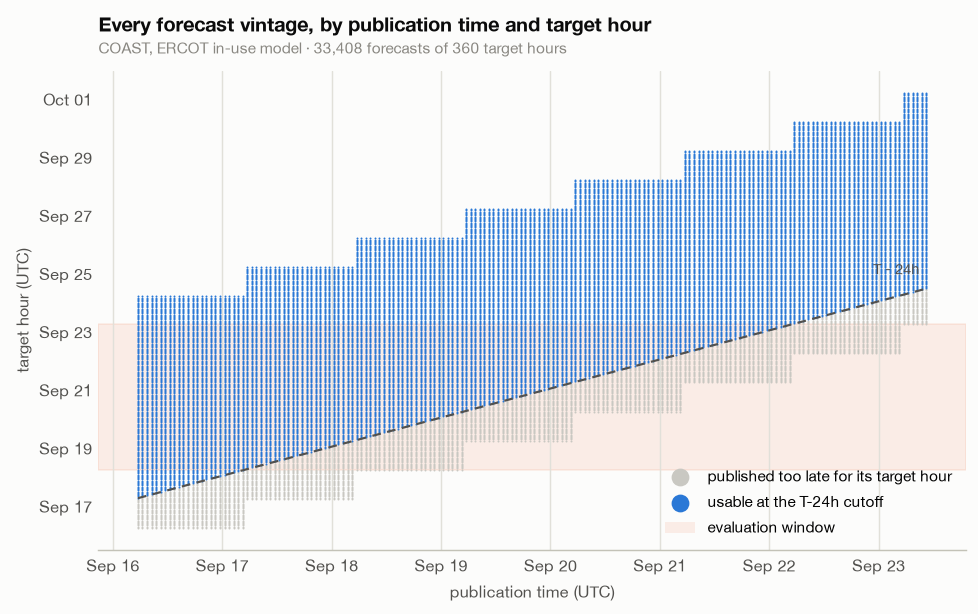

81.2% of published forecasts were eligible for their target hour


In [2]:
landscape = con.execute(
    '''
    SELECT publication_ts_utc, target_ts_utc,
           publication_ts_utc <= target_ts_utc - INTERVAL 24 HOUR AS eligible
    FROM forecast_vintage
    WHERE weather_zone = 'COAST' AND is_ercot_model_in_use
    '''
).df()

fig, ax = plt.subplots(figsize=(7.6, 4.8))
for eligible, color, label, z in (
    (False, viz.CONTEXT, "published too late for its target hour", 1),
    (True, viz.SERIES_ACTUAL, "usable at the T-24h cutoff", 2),
):
    subset = landscape[landscape.eligible == eligible]
    ax.scatter(subset.publication_ts_utc, subset.target_ts_utc, s=1.2, c=color,
               label=label, zorder=z, linewidths=0)

low, high = landscape.publication_ts_utc.min(), landscape.publication_ts_utc.max()
ax.plot([low, high], [low + dt.timedelta(hours=24), high + dt.timedelta(hours=24)],
        color=viz.INK_SECONDARY, lw=1.2, ls=(0, (4, 3)), zorder=3)
ax.annotate("T - 24h", xy=(high, high + dt.timedelta(hours=24)), xytext=(-4, 8),
            textcoords="offset points", ha="right", fontsize=8, color=viz.INK_SECONDARY)
ax.axhspan(context.window_start_utc, context.window_end_utc,
           color=viz.SERIES_ERCOT, alpha=0.10, zorder=0)
viz.frame(ax, x_grid=True)
viz.title(ax, "Every forecast vintage, by publication time and target hour",
          f"COAST, ERCOT in-use model · {len(landscape):,} forecasts of "
          f"{landscape.target_ts_utc.nunique()} target hours")
from matplotlib.patches import Patch

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor=viz.SERIES_ERCOT, alpha=0.10, label="evaluation window"))
ax.legend(handles=handles, loc="lower right", markerscale=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_xlabel("publication time (UTC)")
ax.set_ylabel("target hour (UTC)")
fig.tight_layout()
plt.show()

print(f"{landscape.eligible.mean():.1%} of published forecasts were eligible for their target hour")

## 2. What the as-of selection actually picks

Zoom into a single target hour — the COAST daily peak — and plot every forecast
ever published for it, in publication order.

The forecast converges on the actual as publication approaches the hour. That
convergence is exactly what a historical evaluation must *not* help itself to.
The pipeline takes the last value on the left of the cutoff, not the best value
on the chart.

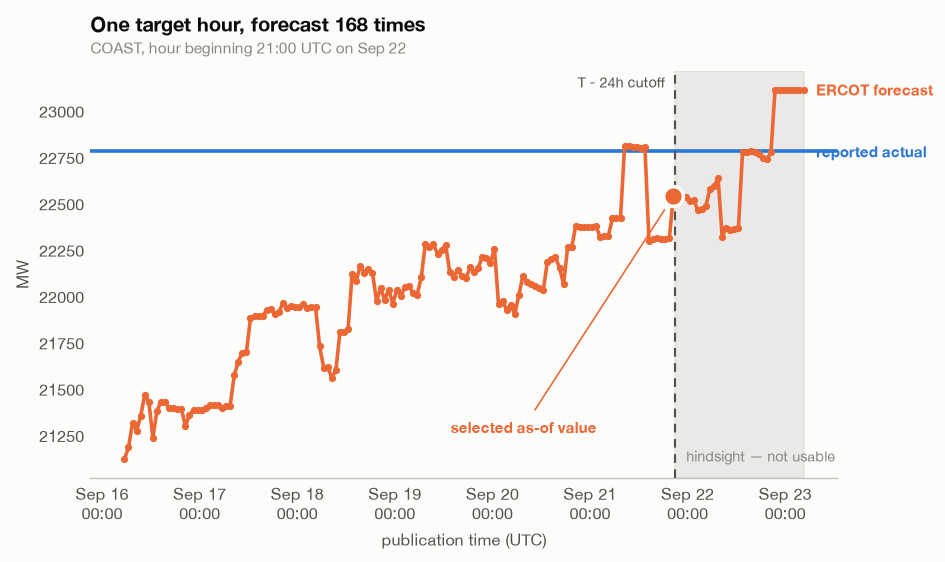

as-of forecast 22,534 MW  ·  actual 22,775 MW  ·  error -241 MW
best forecast ever published for this hour: 22,774 MW


In [3]:
peak_hour = con.execute(
    '''
    SELECT target_ts_utc, actual_mw, ercot_forecast_mw, ercot_publication_ts_utc, cutoff_ts_utc
    FROM evaluation_dataset
    WHERE weather_zone = 'COAST'
    ORDER BY actual_mw DESC
    LIMIT 1
    '''
).fetchone()
target_ts, actual_mw, asof_mw, asof_publication, cutoff_ts = peak_hour

fan = con.execute(
    '''
    SELECT publication_ts_utc, forecast_mw
    FROM forecast_vintage
    WHERE weather_zone = 'COAST' AND is_ercot_model_in_use AND target_ts_utc = ?
    ORDER BY publication_ts_utc
    ''',
    [target_ts],
).df()

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.axvspan(cutoff_ts, fan.publication_ts_utc.max(), color=viz.CONTEXT, alpha=0.35, zorder=0)
ax.annotate("hindsight — not usable", xy=(cutoff_ts, 0.04), xytext=(6, 0),
            xycoords=("data", "axes fraction"), textcoords="offset points",
            fontsize=8, color=viz.INK_MUTED)

ax.plot(fan.publication_ts_utc, fan.forecast_mw, color=viz.SERIES_ERCOT,
        marker="o", ms=3, zorder=3)
ax.axhline(actual_mw, color=viz.SERIES_ACTUAL, lw=2, zorder=2)
ax.axvline(cutoff_ts, color=viz.INK_SECONDARY, lw=1.2, ls=(0, (4, 3)), zorder=4)
ax.annotate("T - 24h cutoff", xy=(cutoff_ts, 0.96), xytext=(-6, 0),
            xycoords=("data", "axes fraction"), textcoords="offset points",
            ha="right", fontsize=8, color=viz.INK_SECONDARY)

ax.scatter([asof_publication], [asof_mw], s=120, facecolor=viz.SERIES_ERCOT,
           edgecolor=viz.SURFACE, linewidths=2, zorder=5)
ax.annotate("selected as-of value", xy=(asof_publication, asof_mw), xytext=(0.58, 0.11),
            textcoords="axes fraction", ha="center", fontsize=8.5,
            weight="bold", color=viz.SERIES_ERCOT,
            arrowprops={"arrowstyle": "-", "color": viz.SERIES_ERCOT,
                        "linewidth": 0.9, "shrinkB": 9, "shrinkA": 3})

viz.frame(ax)
viz.title(ax, f"One target hour, forecast {len(fan)} times",
          f"COAST, hour beginning {target_ts:%H:%M} UTC on {target_ts:%b %d}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
ax.set_ylabel("MW")
ax.set_xlabel("publication time (UTC)")
fig.tight_layout(rect=(0, 0, 0.87, 1))
viz.endpoint_labels(ax, [
    (fan.publication_ts_utc.max(), actual_mw, "reported actual", viz.SERIES_ACTUAL),
    (fan.publication_ts_utc.max(), fan.forecast_mw.iloc[-1], "ERCOT forecast", viz.SERIES_ERCOT),
])
plt.show()

print(f"as-of forecast {asof_mw:,.0f} MW  ·  actual {actual_mw:,.0f} MW  "
      f"·  error {asof_mw - actual_mw:+,.0f} MW")
print(f"best forecast ever published for this hour: "
      f"{fan.forecast_mw.iloc[(fan.forecast_mw - actual_mw).abs().argmin()]:,.0f} MW")

## 3. What hindsight is worth

Change one predicate — take the *latest* vintage for each target hour instead of
the latest one publishable by the cutoff — and rerun the same evaluation on the
same data.

Nothing errors. No row goes missing. Every chart still renders. The model simply
looks considerably better than it was.

This is the failure mode the whole pipeline is built around: not a crash, a
plausible number.

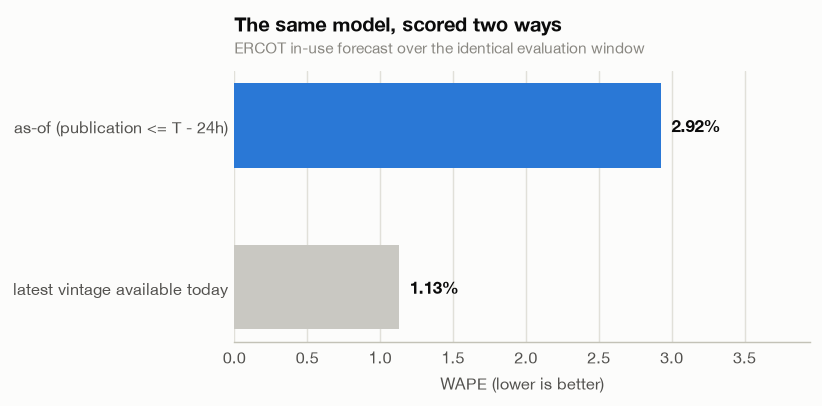

                selection rule   WAPE %
as-of (publication <= T - 24h) 2.924819
latest vintage available today 1.129208

Hindsight would report the model 2.6x better than it was at decision time.
The seasonal-naive model is unaffected by this particular trap: its input is an actual
from seven days earlier, published six days before the cutoff, and NP6-345 was never
observed to revise. A model being immune to one leak is not evidence the pipeline is safe.


In [4]:
hindsight_wape = con.execute(
    '''
    WITH latest AS (
        SELECT weather_zone, target_ts_utc, forecast_mw,
               row_number() OVER (PARTITION BY weather_zone, target_ts_utc
                                  ORDER BY publication_ts_utc DESC) AS rn
        FROM forecast_vintage
        WHERE is_ercot_model_in_use AND weather_zone <> 'SYSTEM_TOTAL'
    )
    SELECT 100 * sum(abs(l.forecast_mw - e.actual_mw)) / sum(e.actual_mw)
    FROM evaluation_dataset e
    JOIN latest l USING (weather_zone, target_ts_utc)
    WHERE l.rn = 1
    '''
).fetchone()[0]

comparison = pd.DataFrame(
    {
        "selection rule": ["as-of (publication <= T - 24h)", "latest vintage available today"],
        "WAPE %": [ercot_model.wape_pct, hindsight_wape],
    }
)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
bars = ax.barh(comparison["selection rule"], comparison["WAPE %"],
               height=0.52, color=[viz.SERIES_ACTUAL, viz.CONTEXT], zorder=2)
for bar, value in zip(bars, comparison["WAPE %"]):
    ax.annotate(f"{value:.2f}%", xy=(value, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9.5, weight="bold", color=viz.INK)
viz.frame(ax)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.invert_yaxis()
ax.set_xlim(0, max(comparison["WAPE %"]) * 1.35)
viz.title(ax, "The same model, scored two ways",
          "ERCOT in-use forecast over the identical evaluation window")
ax.set_xlabel("WAPE (lower is better)")
fig.tight_layout()
plt.show()

print(comparison.to_string(index=False))
print(f"\nHindsight would report the model {ercot_model.wape_pct / hindsight_wape:.1f}x better "
      f"than it was at decision time.")
print("The seasonal-naive model is unaffected by this particular trap: its input is an actual\n"
      "from seven days earlier, published six days before the cutoff, and NP6-345 was never\n"
      "observed to revise. A model being immune to one leak is not evidence the pipeline is safe.")

## 4. Why 24 hours costs what it costs

The gap between those two numbers is not arbitrary — it is the accuracy ERCOT
gains in the final day before an hour arrives.

Scoring every vintage by how far ahead it was published makes the trade explicit.
Note the region left of zero: ERCOT's seven-day file published at 05:30 also
restates hours *earlier that same day* which have already happened. Those rows
are, quite literally, published after the fact, and they are what a "latest
vintage" rule silently reaches for.

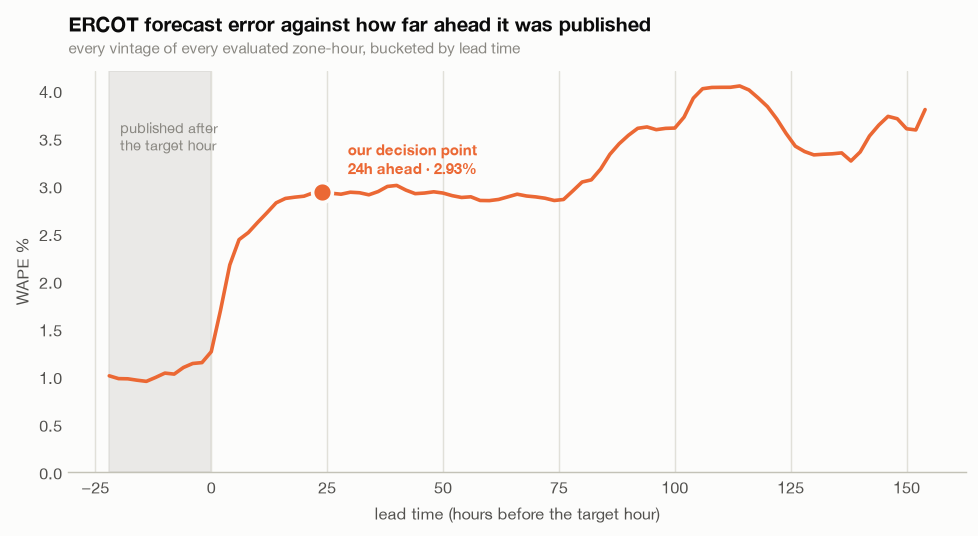

 lead_hours  wape  observations
          0  1.26          1920
          6  2.43          1920
         12  2.71          1920
         24  2.93          1920
         48  2.93          1912
         96  3.59          1144
        144  3.63           376


In [5]:
lead = con.execute(
    '''
    SELECT CAST(date_diff('minute', f.publication_ts_utc, f.target_ts_utc) / 60 AS INTEGER) AS lead_hours,
           100 * sum(abs(f.forecast_mw - e.actual_mw)) / sum(e.actual_mw) AS wape,
           count(*) AS observations
    FROM forecast_vintage f
    JOIN evaluation_dataset e USING (weather_zone, target_ts_utc)
    WHERE f.is_ercot_model_in_use
    GROUP BY 1
    HAVING count(*) >= 200
    ORDER BY 1
    '''
).df()

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.axvspan(lead.lead_hours.min(), 0, color=viz.CONTEXT, alpha=0.35, zorder=0)
ax.annotate("published after\nthe target hour", xy=(lead.lead_hours.min(), 0.88),
            xytext=(6, 0), xycoords=("data", "axes fraction"),
            textcoords="offset points", fontsize=8, color=viz.INK_MUTED, va="top")
ax.plot(lead.lead_hours, lead.wape, color=viz.SERIES_ERCOT, zorder=3)

decision = lead.loc[(lead.lead_hours - 24).abs().idxmin()]
ax.scatter([decision.lead_hours], [decision.wape], s=120, facecolor=viz.SERIES_ERCOT,
           edgecolor=viz.SURFACE, linewidths=2, zorder=4)
ax.annotate(f"our decision point\n24h ahead · {decision.wape:.2f}%",
            xy=(decision.lead_hours, decision.wape), xytext=(14, 10),
            textcoords="offset points", fontsize=8.5, color=viz.SERIES_ERCOT, weight="bold")

viz.frame(ax, x_grid=True)
viz.title(ax, "ERCOT forecast error against how far ahead it was published",
          "every vintage of every evaluated zone-hour, bucketed by lead time")
ax.set_xlabel("lead time (hours before the target hour)")
ax.set_ylabel("WAPE %")
ax.set_ylim(0, None)
fig.tight_layout()
plt.show()

print(lead[lead.lead_hours.isin([0, 6, 12, 24, 48, 96, 144])]
      .assign(wape=lambda d: d.wape.round(2)).to_string(index=False))

## 5. The evaluation dataset itself

With the selection settled, this is what is actually being scored: the reported
actual, ERCOT's own as-of forecast, and the weekly seasonal-naive forecast the
gate judges.

ERCOT's model is shown for context, not as a competitor — the exercise asks for
one model. It is here because its vintages are the material the point-in-time
machinery is built on, and because it sets a useful floor on what this window
was capable of.

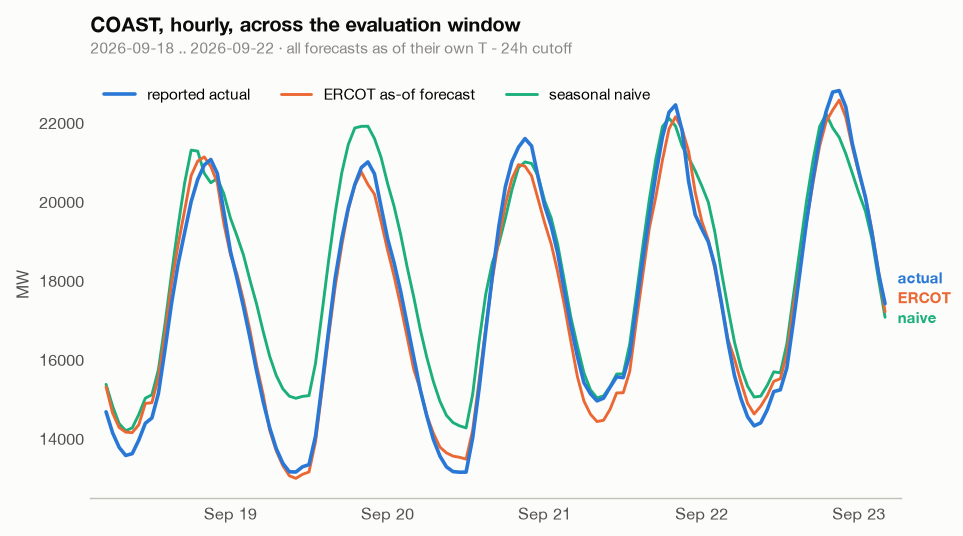

         model  WAPE %  worst day %  worst peak-hour APE %
seasonal naive    6.35         7.40                  16.20
  ERCOT in-use    2.92         3.35                  11.19


In [6]:
series = con.execute(
    '''
    SELECT target_ts_utc, actual_mw, ercot_forecast_mw, naive_forecast_mw
    FROM evaluation_dataset
    WHERE weather_zone = 'COAST'
    ORDER BY target_ts_utc
    '''
).df()

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(series.target_ts_utc, series.actual_mw, color=viz.SERIES_ACTUAL,
        label="reported actual", zorder=4)
ax.plot(series.target_ts_utc, series.ercot_forecast_mw, color=viz.SERIES_ERCOT,
        lw=1.6, label="ERCOT as-of forecast", zorder=3)
ax.plot(series.target_ts_utc, series.naive_forecast_mw, color=viz.SERIES_NAIVE,
        lw=1.6, label="seasonal naive", zorder=2)

viz.frame(ax)
viz.title(ax, "COAST, hourly, across the evaluation window",
          f"{first_day} .. {last_day} · all forecasts as of their own T - 24h cutoff")
ax.legend(loc="upper left", ncols=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_ylabel("MW")
ax.margins(x=0.02)
fig.tight_layout(rect=(0, 0, 0.91, 1))

last = series.iloc[-1]
viz.endpoint_labels(ax, [
    (last.target_ts_utc, last.actual_mw, "actual", viz.SERIES_ACTUAL),
    (last.target_ts_utc, last.ercot_forecast_mw, "ERCOT", viz.SERIES_ERCOT),
    (last.target_ts_utc, last.naive_forecast_mw, "naive", viz.SERIES_NAIVE),
])
plt.show()

print(pd.DataFrame({
    "model": ["seasonal naive", "ERCOT in-use"],
    "WAPE %": [round(naive.wape_pct, 2), round(ercot_model.wape_pct, 2)],
    "worst day %": [round(naive.worst_fold_wape_pct, 2), round(ercot_model.worst_fold_wape_pct, 2)],
    "worst peak-hour APE %": [round(naive.max_peak_hour_ape_pct, 2),
                              round(ercot_model.max_peak_hour_ape_pct, 2)],
}).to_string(index=False))

## 6. Where the error lives

A single WAPE hides structure. Broken out by weather zone and hour of the local
operating day, the seasonal-naive error is clearly not uniform — it concentrates
in particular zones and particular hours, which is what a threshold on the
pooled number cannot see.

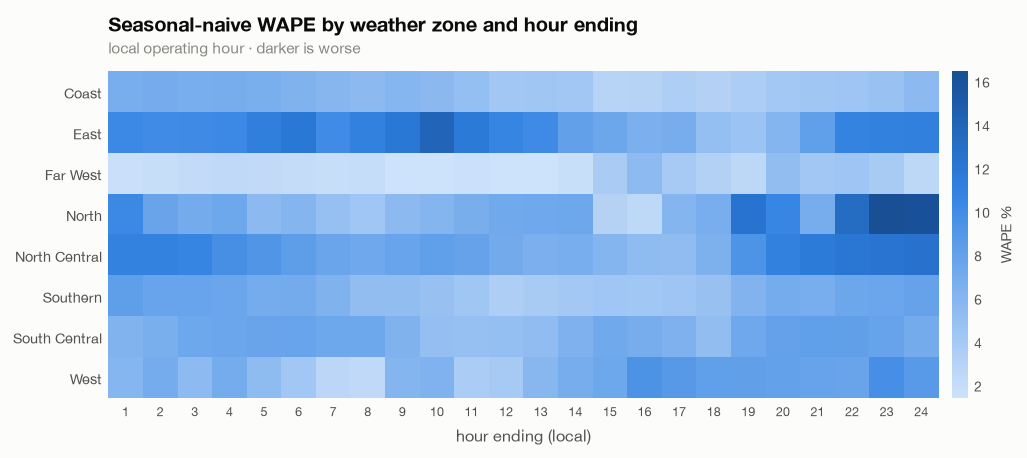

worst zone-hours (WAPE %):
weather_zone   hour_ending
NORTH          23             16.46
               24             16.13
EAST           10             13.89
NORTH          22             13.16
NORTH_CENTRAL  24             12.51


In [7]:
heat = (
    con.execute(
        '''
        SELECT weather_zone, hour_ending,
               100 * sum(abs(naive_error_mw)) / sum(actual_mw) AS wape
        FROM evaluation_dataset
        GROUP BY 1, 2
        '''
    )
    .df()
    .pivot(index="weather_zone", columns="hour_ending", values="wape")
    .sort_index()
)

from matplotlib.colors import LinearSegmentedColormap

ramp = LinearSegmentedColormap.from_list("sequential_blue", viz.SEQUENTIAL)

fig, ax = plt.subplots(figsize=(8.0, 3.6))
image = ax.imshow(heat.values, aspect="auto", cmap=ramp, origin="upper")
ax.set_xticks(range(len(heat.columns)), [str(h) for h in heat.columns], fontsize=7)
ax.set_yticks(range(len(heat.index)), [z.replace("_", " ").title() for z in heat.index], fontsize=8)
ax.grid(visible=False)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)
viz.title(ax, "Seasonal-naive WAPE by weather zone and hour ending",
          "local operating hour · darker is worse")
ax.set_xlabel("hour ending (local)")
bar = fig.colorbar(image, ax=ax, pad=0.015, fraction=0.03)
bar.set_label("WAPE %", color=viz.INK_SECONDARY, fontsize=8)
bar.outline.set_visible(False)
bar.ax.tick_params(labelsize=7.5, color=viz.INK_MUTED, labelcolor=viz.INK_SECONDARY)
fig.tight_layout()
plt.show()

worst = heat.stack().sort_values(ascending=False).head(5)
print("worst zone-hours (WAPE %):")
print(worst.round(2).to_string())

## 7. Rolling origin, never a random split

Every fold's inputs precede its target, so evaluation runs sequentially by
operating day. The gate checks the window average *and* each individual day —
an acceptable mean must not be covering an unacceptable day.

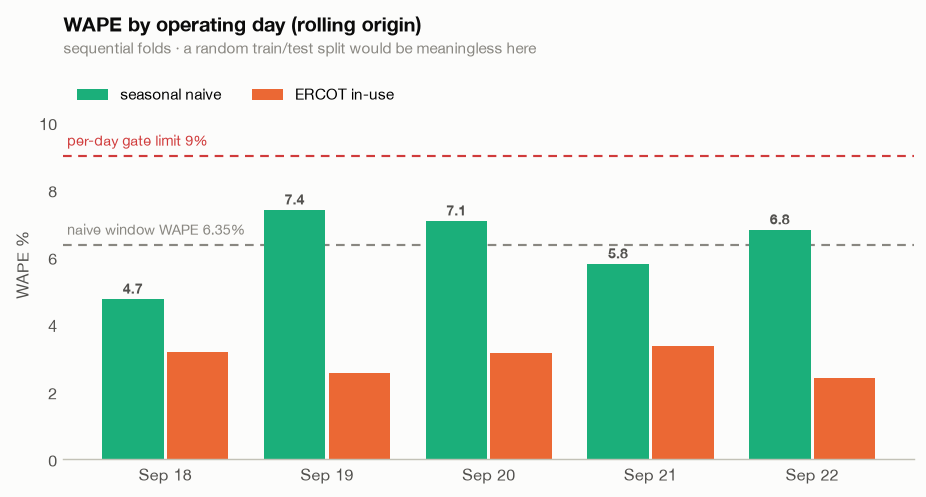

       day  naive  ercot
2026-09-18   4.75   3.17
2026-09-19   7.40   2.54
2026-09-20   7.07   3.16
2026-09-21   5.80   3.35
2026-09-22   6.81   2.40


In [8]:
folds = pd.DataFrame(
    [{"day": f.operating_date, "naive": f.wape_pct} for f in naive.folds]
).merge(
    pd.DataFrame([{"day": f.operating_date, "ercot": f.wape_pct} for f in ercot_model.folds]),
    on="day",
)

thresholds = gates.Thresholds()
positions = range(len(folds))
width = 0.38

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.bar([p - width / 2 - 0.01 for p in positions], folds["naive"], width,
       color=viz.SERIES_NAIVE, label="seasonal naive", zorder=2)
ax.bar([p + width / 2 + 0.01 for p in positions], folds["ercot"], width,
       color=viz.SERIES_ERCOT, label="ERCOT in-use", zorder=2)
for position, value in zip(positions, folds["naive"]):
    ax.annotate(f"{value:.1f}", xy=(position - width / 2 - 0.01, value), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=8,
                color=viz.INK_SECONDARY, weight="bold")

viz.threshold(ax, thresholds.max_fold_wape_pct,
              f"per-day gate limit {thresholds.max_fold_wape_pct:.0f}%",
              color=viz.STATUS_CRITICAL, ha="left")
viz.threshold(ax, naive.wape_pct, f"naive window WAPE {naive.wape_pct:.2f}%", ha="left")

viz.frame(ax)
viz.title(ax, "WAPE by operating day (rolling origin)",
          "sequential folds · a random train/test split would be meaningless here")
ax.set_xticks(list(positions), [d.strftime("%b %d") for d in folds["day"]])
ax.set_ylabel("WAPE %")
ax.set_ylim(0, thresholds.max_fold_wape_pct * 1.28)
ax.legend(loc="upper left", ncols=2)
fig.tight_layout()
plt.show()

print(folds.round(2).to_string(index=False))

## 8. The guardrail that overall WAPE cannot provide

A model can post a respectable window average and still be badly wrong exactly
where error is expensive. Each point below is one evaluated zone-hour; the
highlighted ones are each zone-day's peak hour.

The gate therefore carries a second, independent limit on peak-hour error.
`tests/test_gates.py::test_a_good_average_does_not_excuse_a_bad_peak_hour`
corrupts a single zone-day peak, confirms overall WAPE still passes, and shows
this guardrail is what refuses the release.

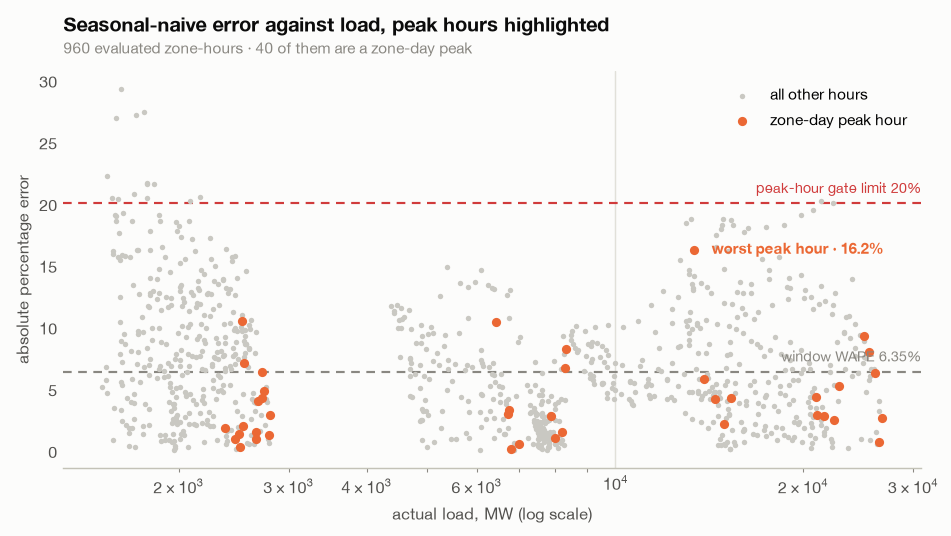

overall WAPE 6.35% passes the 8% limit
worst peak-hour APE 16.20% against a 20% limit — headroom, but not much


In [9]:
points = con.execute(
    '''
    SELECT actual_mw,
           100 * abs(naive_error_mw) / actual_mw AS ape,
           row_number() OVER (PARTITION BY weather_zone, operating_date
                              ORDER BY actual_mw DESC) = 1 AS is_peak
    FROM evaluation_dataset
    WHERE actual_mw > 0 AND naive_forecast_mw IS NOT NULL
    '''
).df()

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ordinary = points[~points.is_peak]
peaks = points[points.is_peak]
ax.scatter(ordinary.actual_mw, ordinary.ape, s=9, c=viz.CONTEXT,
           label="all other hours", linewidths=0, zorder=2)
ax.scatter(peaks.actual_mw, peaks.ape, s=26, c=viz.SERIES_ERCOT,
           label="zone-day peak hour", linewidths=0, zorder=3)

viz.threshold(ax, gates.Thresholds().max_peak_hour_ape_pct,
              f"peak-hour gate limit {gates.Thresholds().max_peak_hour_ape_pct:.0f}%",
              color=viz.STATUS_CRITICAL)
viz.threshold(ax, naive.wape_pct, f"window WAPE {naive.wape_pct:.2f}%")

worst_peak = peaks.loc[peaks.ape.idxmax()]
ax.annotate(f"worst peak hour · {worst_peak.ape:.1f}%",
            xy=(worst_peak.actual_mw, worst_peak.ape), xytext=(10, -2),
            textcoords="offset points", fontsize=8.5, weight="bold", color=viz.SERIES_ERCOT)

viz.frame(ax, x_grid=True)
viz.title(ax, "Seasonal-naive error against load, peak hours highlighted",
          f"{len(points)} evaluated zone-hours · {len(peaks)} of them are a zone-day peak")
ax.set_xscale("log")
ax.set_xlabel("actual load, MW (log scale)")
ax.set_ylabel("absolute percentage error")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

print(f"overall WAPE {naive.wape_pct:.2f}% passes the {gates.Thresholds().max_wape_pct:.0f}% limit")
print(f"worst peak-hour APE {peaks.ape.max():.2f}% against a "
      f"{gates.Thresholds().max_peak_hour_ape_pct:.0f}% limit — headroom, but not much")

## 9. A local operating day is not 24 hours

Coverage checks that hard-code 24 are wrong twice a year. The readiness gate
derives the expected count from the calendar instead, so a DST day is not
reported as missing data — and a DST day that *does* have 24 rows is.

The same reasoning drives the seasonal-naive lag: seven calendar days at the
same local hour is 167 or 169 hours across a transition, so the join is on
`(operating_date − 7, hour_ending, dst_flag)` rather than on arithmetic.

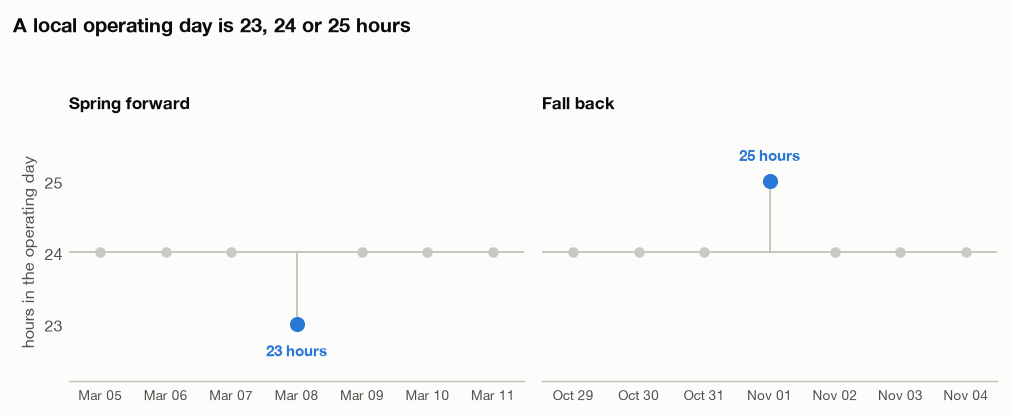

transition  Fall back  Spring forward
day                                  
2026-03-05        NaN            24.0
2026-03-06        NaN            24.0
2026-03-07        NaN            24.0
2026-03-08        NaN            23.0
2026-03-09        NaN            24.0
2026-03-10        NaN            24.0
2026-03-11        NaN            24.0
2026-10-29       24.0             NaN
2026-10-30       24.0             NaN
2026-10-31       24.0             NaN
2026-11-01       25.0             NaN
2026-11-02       24.0             NaN
2026-11-03       24.0             NaN
2026-11-04       24.0             NaN

expected evaluation rows for this window: observed 960


In [10]:
def transition_week(centre: dt.date) -> pd.DataFrame:
    days = [centre + dt.timedelta(days=offset) for offset in range(-3, 4)]
    return pd.DataFrame({"day": days, "hours": [hours_in_operating_date(d) for d in days]})

weeks = [("Spring forward", transition_week(dt.date(2026, 3, 8))),
         ("Fall back", transition_week(dt.date(2026, 11, 1)))]

# A dot plot, not bars: 23 against 24 is a one-part-in-24 difference that a
# zero-baselined bar cannot show, and truncating a bar axis would misencode
# length. Dots encode position, so a tight axis is honest here.
fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.2), sharey=True)
for ax, (label, week) in zip(axes, weeks):
    ax.axhline(24, color=viz.BASELINE, lw=1, zorder=1)
    for position, hours in enumerate(week.hours):
        odd = hours != 24
        ax.plot([position, position], [24, hours], color=viz.BASELINE, lw=1, zorder=1)
        ax.scatter([position], [hours], s=70 if odd else 34,
                   c=viz.SERIES_ACTUAL if odd else viz.CONTEXT, zorder=3, linewidths=0)
        if odd:
            ax.annotate(f"{hours} hours", xy=(position, hours),
                        xytext=(0, 11 if hours > 24 else -18), textcoords="offset points",
                        ha="center", fontsize=8.5, weight="bold", color=viz.SERIES_ACTUAL)
    viz.frame(ax)
    ax.grid(axis="y", visible=False)
    ax.set_title(label, fontsize=9.5, color=viz.INK, loc="left", pad=8, weight="bold")
    ax.set_xticks(range(len(week)), [d.strftime("%b %d") for d in week.day], fontsize=7.5)
    ax.set_ylim(22.2, 25.8)
    ax.set_yticks([23, 24, 25])
    ax.margins(x=0.08)
axes[0].set_ylabel("hours in the operating day")
fig.suptitle("A local operating day is 23, 24 or 25 hours",
             fontsize=11, color=viz.INK, x=0.012, ha="left", weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

print(pd.concat([week.assign(transition=label) for label, week in weeks])
      .pivot(index="day", columns="transition", values="hours")
      .to_string())
print("")
print(f"expected evaluation rows for this window: "
      f"observed {readiness.metrics['evaluation_rows']}")

## Regenerating this notebook

```bash
uv pip install -e ".[dev,notebook]"
uv run forecast-spine acquire          # ~12 MB of MIS vintages, no credentials
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/exploration.ipynb
```

Chart conventions are in `src/forecast_spine/viz.py`: one y-axis per chart,
colour follows the entity so "actual" is the same blue throughout, solid
hairline gridlines with dashing reserved for labelled thresholds, and a printed
table beside every figure so nothing depends on colour alone.

The narrative behind these charts, with the measured source-behaviour evidence,
is in `MEMO.md`.